In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import torch
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT
from torch_geometric.datasets import WebKB
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [37]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Wisconsin", node_feature_type="PyG")

In [38]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      'split_idx': 2
  }

In [39]:
dataset = WebKB(root ='tmp/Wisconsin', name='Wisconsin')

In [40]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 1703
Number of num_classes : 5
Number of num_nodes : 251
Number of num_edges : 515


In [41]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [43]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [44]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [45]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [46]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


## GCN Run


>>> RUNNING SPLIT 0 / 9
Training GCN
Epoch: 010, Loss: 0.7305, Val F1: 0.2720,Val Acc: 0.4250, Time: 0.00s
Epoch: 020, Loss: 0.6741, Val F1: 0.3769,Val Acc: 0.4625, Time: 0.00s
Epoch: 030, Loss: 0.4817, Val F1: 0.2836,Val Acc: 0.4000, Time: 0.00s
Epoch: 040, Loss: 0.4116, Val F1: 0.4604,Val Acc: 0.4875, Time: 0.00s
Epoch: 050, Loss: 0.4123, Val F1: 0.4206,Val Acc: 0.4750, Time: 0.00s
Epoch: 060, Loss: 0.3374, Val F1: 0.3426,Val Acc: 0.4250, Time: 0.00s
Epoch: 070, Loss: 0.2797, Val F1: 0.3037,Val Acc: 0.4000, Time: 0.00s
Epoch: 080, Loss: 0.2446, Val F1: 0.3477,Val Acc: 0.4500, Time: 0.00s
Epoch: 090, Loss: 0.2222, Val F1: 0.3203,Val Acc: 0.4625, Time: 0.00s
Epoch: 100, Loss: 0.2176, Val F1: 0.2947,Val Acc: 0.4500, Time: 0.00s
Test F1: 0.2485
Test Accuracy: 0.3725


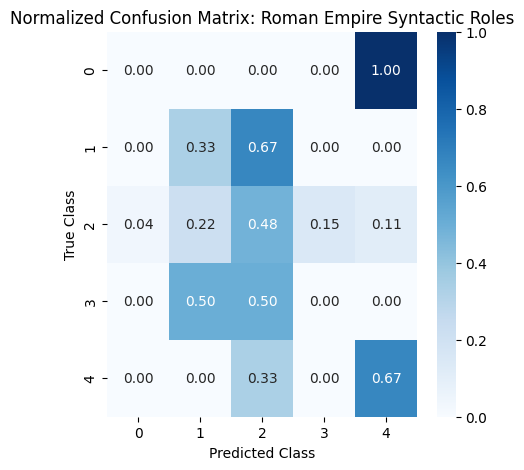

GCN results saved using PyG features.
Training Time 0.648364782333374


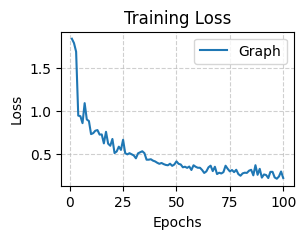

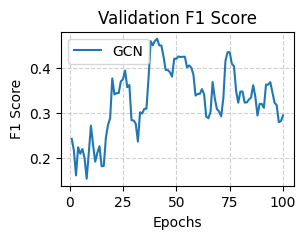

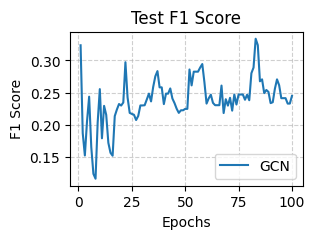


>>> RUNNING SPLIT 1 / 9
Training GCN
Epoch: 010, Loss: 0.8931, Val F1: 0.2403,Val Acc: 0.3250, Time: 0.01s
Epoch: 020, Loss: 0.6239, Val F1: 0.2577,Val Acc: 0.3875, Time: 0.00s
Epoch: 030, Loss: 0.4645, Val F1: 0.2461,Val Acc: 0.3500, Time: 0.00s
Epoch: 040, Loss: 0.3745, Val F1: 0.3536,Val Acc: 0.3875, Time: 0.00s
Epoch: 050, Loss: 0.3598, Val F1: 0.3081,Val Acc: 0.3375, Time: 0.00s
Epoch: 060, Loss: 0.2633, Val F1: 0.3181,Val Acc: 0.3375, Time: 0.00s
Epoch: 070, Loss: 0.2406, Val F1: 0.2980,Val Acc: 0.3250, Time: 0.00s
Epoch: 080, Loss: 0.2407, Val F1: 0.3172,Val Acc: 0.3500, Time: 0.00s
Epoch: 090, Loss: 0.1816, Val F1: 0.2976,Val Acc: 0.3250, Time: 0.00s
Epoch: 100, Loss: 0.1260, Val F1: 0.3126,Val Acc: 0.3500, Time: 0.00s
Test F1: 0.3568
Test Accuracy: 0.5490


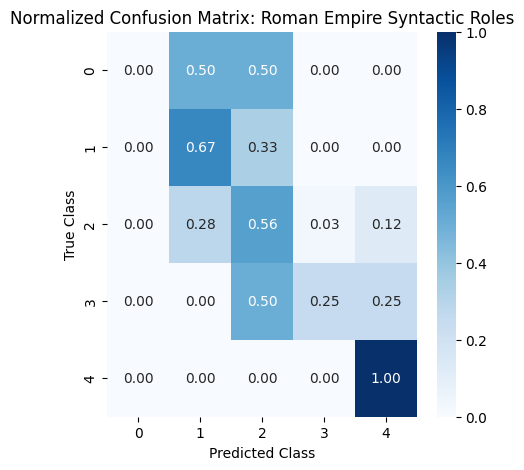

GCN results saved using PyG features.
Training Time 0.47176265716552734


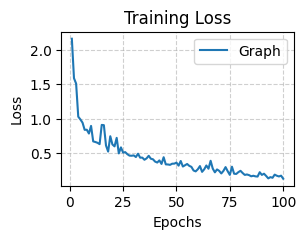

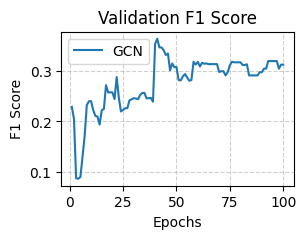

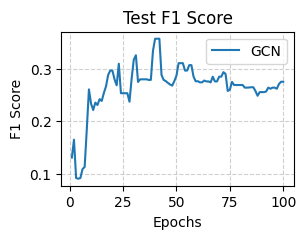


>>> RUNNING SPLIT 2 / 9
Training GCN
Epoch: 010, Loss: 0.5927, Val F1: 0.2451,Val Acc: 0.3875, Time: 0.00s
Epoch: 020, Loss: 0.4473, Val F1: 0.2474,Val Acc: 0.4000, Time: 0.00s
Epoch: 030, Loss: 0.3764, Val F1: 0.3906,Val Acc: 0.4125, Time: 0.00s
Epoch: 040, Loss: 0.2766, Val F1: 0.4299,Val Acc: 0.4875, Time: 0.00s
Epoch: 050, Loss: 0.3447, Val F1: 0.4127,Val Acc: 0.4625, Time: 0.00s
Epoch: 060, Loss: 0.1978, Val F1: 0.3395,Val Acc: 0.4250, Time: 0.00s
Epoch: 070, Loss: 0.1719, Val F1: 0.3809,Val Acc: 0.4375, Time: 0.00s
Epoch: 080, Loss: 0.1846, Val F1: 0.3884,Val Acc: 0.4375, Time: 0.00s
Epoch: 090, Loss: 0.1845, Val F1: 0.3725,Val Acc: 0.4375, Time: 0.00s
Epoch: 100, Loss: 0.1496, Val F1: 0.2494,Val Acc: 0.4125, Time: 0.00s
Test F1: 0.2415
Test Accuracy: 0.3725


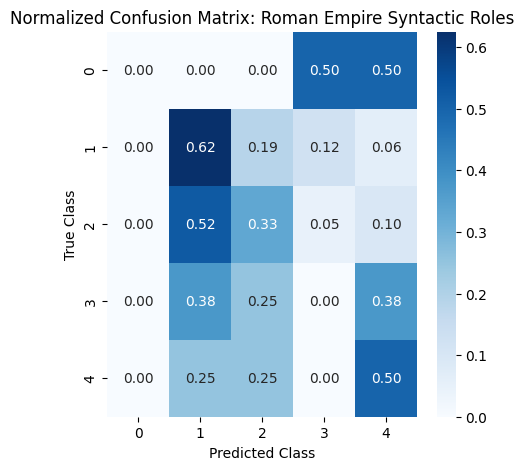

GCN results saved using PyG features.
Training Time 0.4685535430908203


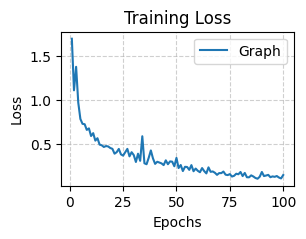

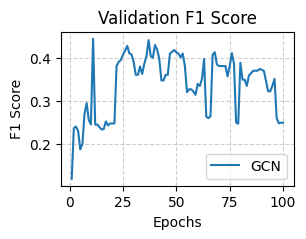

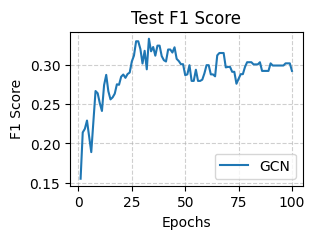


>>> RUNNING SPLIT 3 / 9
Training GCN
Epoch: 010, Loss: 0.7776, Val F1: 0.1411,Val Acc: 0.2625, Time: 0.00s
Epoch: 020, Loss: 0.6176, Val F1: 0.2772,Val Acc: 0.3125, Time: 0.01s
Epoch: 030, Loss: 0.4871, Val F1: 0.3594,Val Acc: 0.3750, Time: 0.00s
Epoch: 040, Loss: 0.4861, Val F1: 0.2622,Val Acc: 0.3500, Time: 0.00s
Epoch: 050, Loss: 0.3625, Val F1: 0.4624,Val Acc: 0.5000, Time: 0.00s
Epoch: 060, Loss: 0.3589, Val F1: 0.4084,Val Acc: 0.4625, Time: 0.00s
Epoch: 070, Loss: 0.3382, Val F1: 0.4292,Val Acc: 0.4750, Time: 0.00s
Epoch: 080, Loss: 0.3670, Val F1: 0.4149,Val Acc: 0.4625, Time: 0.00s
Epoch: 090, Loss: 0.3157, Val F1: 0.3824,Val Acc: 0.4625, Time: 0.00s
Epoch: 100, Loss: 0.2669, Val F1: 0.3871,Val Acc: 0.4750, Time: 0.00s
Test F1: 0.2706
Test Accuracy: 0.3922


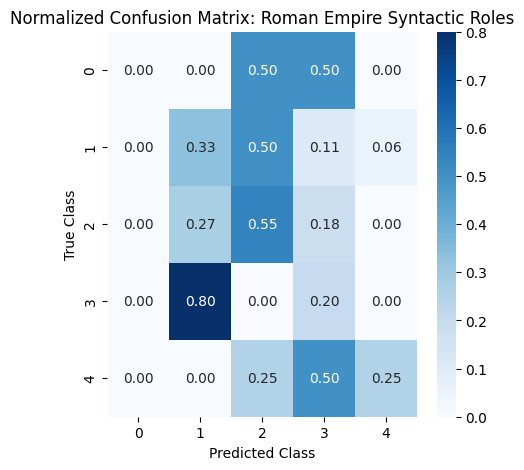

GCN results saved using PyG features.
Training Time 0.4853672981262207


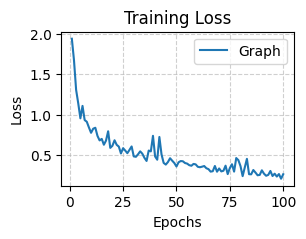

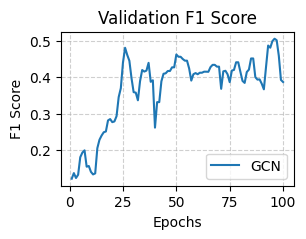

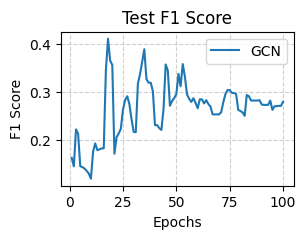


>>> RUNNING SPLIT 4 / 9
Training GCN
Epoch: 010, Loss: 0.7065, Val F1: 0.1685,Val Acc: 0.2625, Time: 0.00s
Epoch: 020, Loss: 0.5726, Val F1: 0.1106,Val Acc: 0.1625, Time: 0.00s
Epoch: 030, Loss: 0.4558, Val F1: 0.1622,Val Acc: 0.2000, Time: 0.01s
Epoch: 040, Loss: 0.4048, Val F1: 0.2076,Val Acc: 0.2250, Time: 0.00s
Epoch: 050, Loss: 0.3384, Val F1: 0.2332,Val Acc: 0.3125, Time: 0.00s
Epoch: 060, Loss: 0.3385, Val F1: 0.2110,Val Acc: 0.3250, Time: 0.00s
Epoch: 070, Loss: 0.2923, Val F1: 0.1945,Val Acc: 0.2750, Time: 0.00s
Epoch: 080, Loss: 0.2348, Val F1: 0.1863,Val Acc: 0.2625, Time: 0.00s
Epoch: 090, Loss: 0.2345, Val F1: 0.2251,Val Acc: 0.3125, Time: 0.00s
Epoch: 100, Loss: 0.2271, Val F1: 0.1962,Val Acc: 0.2625, Time: 0.00s
Test F1: 0.3854
Test Accuracy: 0.4510


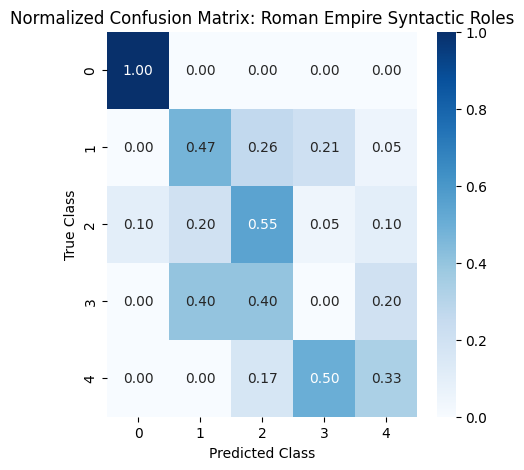

GCN results saved using PyG features.
Training Time 0.47188663482666016


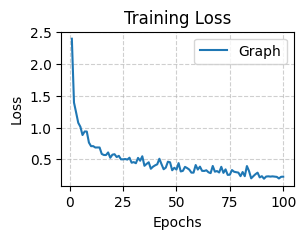

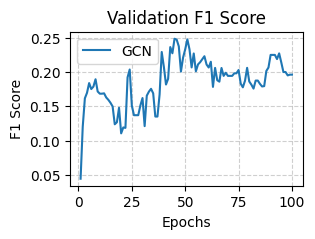

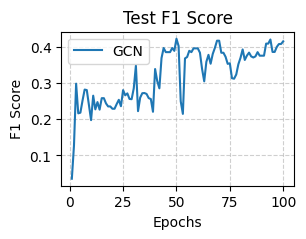


>>> RUNNING SPLIT 5 / 9
Training GCN
Epoch: 010, Loss: 0.6871, Val F1: 0.2091,Val Acc: 0.2750, Time: 0.00s
Epoch: 020, Loss: 0.5146, Val F1: 0.1601,Val Acc: 0.2000, Time: 0.00s
Epoch: 030, Loss: 0.3979, Val F1: 0.1908,Val Acc: 0.2125, Time: 0.00s
Epoch: 040, Loss: 0.4151, Val F1: 0.1958,Val Acc: 0.2500, Time: 0.00s
Epoch: 050, Loss: 0.3146, Val F1: 0.1672,Val Acc: 0.2000, Time: 0.00s
Epoch: 060, Loss: 0.2810, Val F1: 0.2350,Val Acc: 0.4000, Time: 0.00s
Epoch: 070, Loss: 0.2684, Val F1: 0.2561,Val Acc: 0.4125, Time: 0.00s
Epoch: 080, Loss: 0.1972, Val F1: 0.2459,Val Acc: 0.4000, Time: 0.00s
Epoch: 090, Loss: 0.2017, Val F1: 0.2169,Val Acc: 0.3750, Time: 0.00s
Epoch: 100, Loss: 0.1535, Val F1: 0.2358,Val Acc: 0.3875, Time: 0.00s
Test F1: 0.1821
Test Accuracy: 0.3725


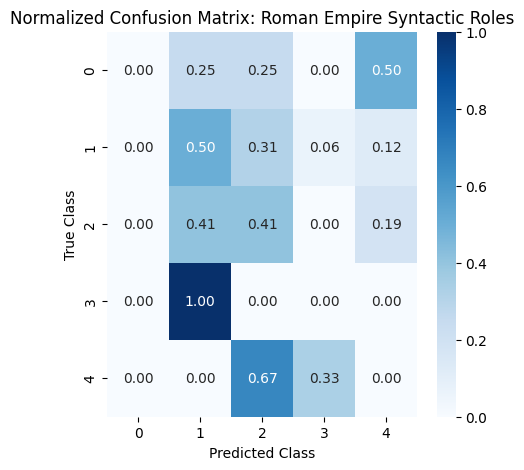

GCN results saved using PyG features.
Training Time 0.46344852447509766


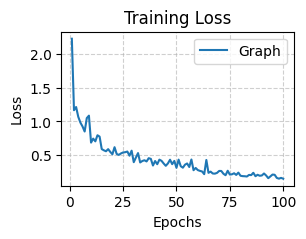

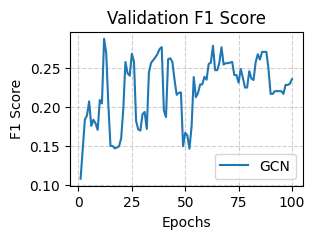

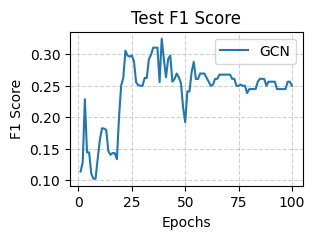


>>> RUNNING SPLIT 6 / 9
Training GCN
Epoch: 010, Loss: 0.9605, Val F1: 0.2396,Val Acc: 0.3000, Time: 0.00s
Epoch: 020, Loss: 0.5967, Val F1: 0.3481,Val Acc: 0.4500, Time: 0.00s
Epoch: 030, Loss: 0.5978, Val F1: 0.3367,Val Acc: 0.3500, Time: 0.00s
Epoch: 040, Loss: 0.4571, Val F1: 0.2407,Val Acc: 0.2875, Time: 0.00s
Epoch: 050, Loss: 0.3403, Val F1: 0.2757,Val Acc: 0.3875, Time: 0.00s
Epoch: 060, Loss: 0.3224, Val F1: 0.3654,Val Acc: 0.4250, Time: 0.00s
Epoch: 070, Loss: 0.2920, Val F1: 0.3397,Val Acc: 0.4000, Time: 0.00s
Epoch: 080, Loss: 0.2711, Val F1: 0.2835,Val Acc: 0.4250, Time: 0.00s
Epoch: 090, Loss: 0.2076, Val F1: 0.3295,Val Acc: 0.4500, Time: 0.00s
Epoch: 100, Loss: 0.1979, Val F1: 0.2903,Val Acc: 0.4125, Time: 0.00s
Test F1: 0.2762
Test Accuracy: 0.4118


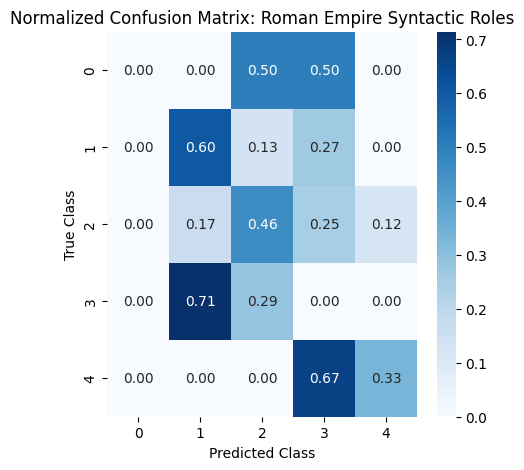

GCN results saved using PyG features.
Training Time 0.46810173988342285


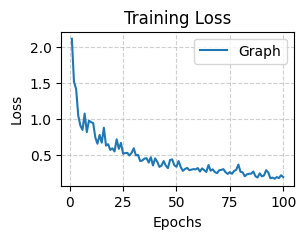

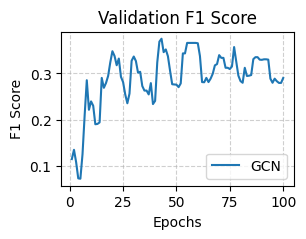

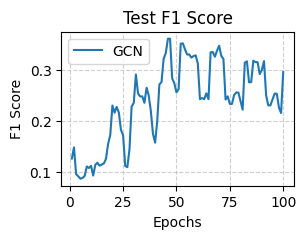


>>> RUNNING SPLIT 7 / 9
Training GCN
Epoch: 010, Loss: 0.8419, Val F1: 0.2150,Val Acc: 0.3125, Time: 0.00s
Epoch: 020, Loss: 0.6034, Val F1: 0.2802,Val Acc: 0.4250, Time: 0.00s
Epoch: 030, Loss: 0.5210, Val F1: 0.2696,Val Acc: 0.4125, Time: 0.00s
Epoch: 040, Loss: 0.4289, Val F1: 0.2936,Val Acc: 0.4625, Time: 0.00s
Epoch: 050, Loss: 0.3588, Val F1: 0.5015,Val Acc: 0.4750, Time: 0.00s
Epoch: 060, Loss: 0.3087, Val F1: 0.2936,Val Acc: 0.4625, Time: 0.00s
Epoch: 070, Loss: 0.2527, Val F1: 0.2900,Val Acc: 0.4500, Time: 0.00s
Epoch: 080, Loss: 0.2182, Val F1: 0.2973,Val Acc: 0.4625, Time: 0.00s
Epoch: 090, Loss: 0.1982, Val F1: 0.2925,Val Acc: 0.4375, Time: 0.00s
Epoch: 100, Loss: 0.1734, Val F1: 0.2911,Val Acc: 0.4500, Time: 0.00s
Test F1: 0.4492
Test Accuracy: 0.5294


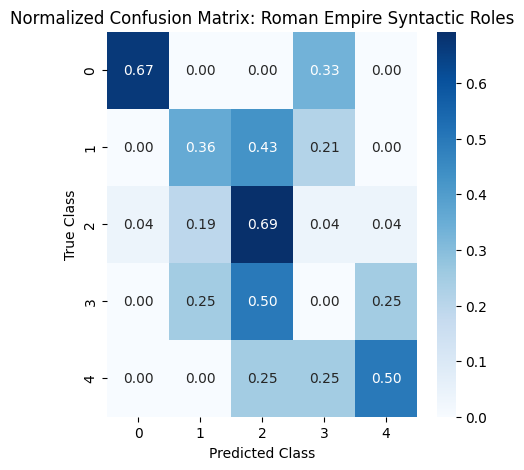

GCN results saved using PyG features.
Training Time 0.46901750564575195


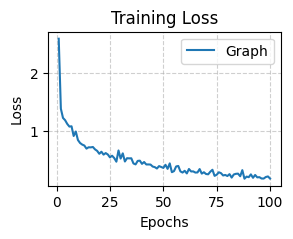

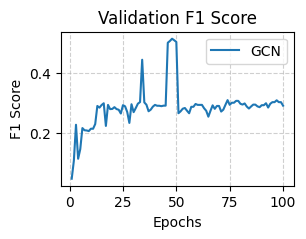

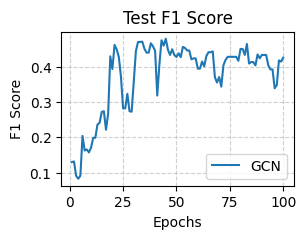


>>> RUNNING SPLIT 8 / 9
Training GCN
Epoch: 010, Loss: 0.6693, Val F1: 0.2980,Val Acc: 0.4125, Time: 0.00s
Epoch: 020, Loss: 0.4491, Val F1: 0.3538,Val Acc: 0.4250, Time: 0.00s
Epoch: 030, Loss: 0.3630, Val F1: 0.3479,Val Acc: 0.3875, Time: 0.00s
Epoch: 040, Loss: 0.3269, Val F1: 0.3482,Val Acc: 0.4125, Time: 0.00s
Epoch: 050, Loss: 0.3442, Val F1: 0.3463,Val Acc: 0.4125, Time: 0.00s
Epoch: 060, Loss: 0.3273, Val F1: 0.3563,Val Acc: 0.4250, Time: 0.00s
Epoch: 070, Loss: 0.3272, Val F1: 0.3177,Val Acc: 0.3875, Time: 0.00s
Epoch: 080, Loss: 0.2773, Val F1: 0.3229,Val Acc: 0.3625, Time: 0.00s
Epoch: 090, Loss: 0.2749, Val F1: 0.3602,Val Acc: 0.4125, Time: 0.00s
Epoch: 100, Loss: 0.2040, Val F1: 0.3514,Val Acc: 0.4125, Time: 0.00s
Test F1: 0.4216
Test Accuracy: 0.4902


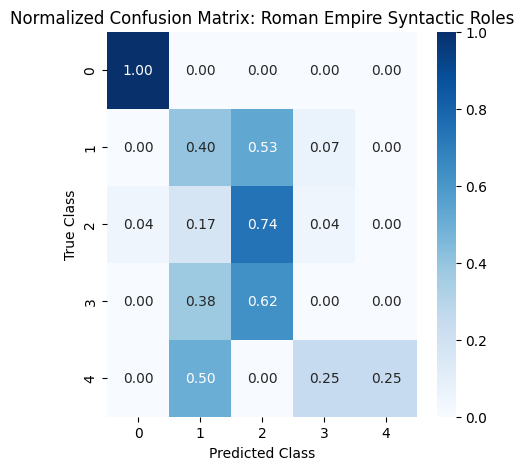

GCN results saved using PyG features.
Training Time 0.469623327255249


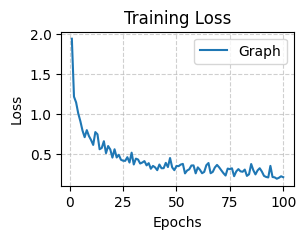

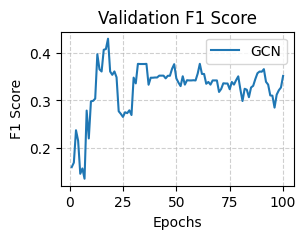

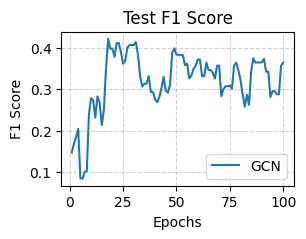


>>> RUNNING SPLIT 9 / 9
Training GCN
Epoch: 010, Loss: 0.8582, Val F1: 0.2218,Val Acc: 0.3125, Time: 0.00s
Epoch: 020, Loss: 0.8028, Val F1: 0.3712,Val Acc: 0.5000, Time: 0.00s
Epoch: 030, Loss: 0.5275, Val F1: 0.3079,Val Acc: 0.4625, Time: 0.00s
Epoch: 040, Loss: 0.5570, Val F1: 0.3166,Val Acc: 0.3625, Time: 0.00s
Epoch: 050, Loss: 0.4899, Val F1: 0.3775,Val Acc: 0.5250, Time: 0.00s
Epoch: 060, Loss: 0.4838, Val F1: 0.4167,Val Acc: 0.5750, Time: 0.00s
Epoch: 070, Loss: 0.3297, Val F1: 0.4151,Val Acc: 0.5750, Time: 0.00s
Epoch: 080, Loss: 0.2567, Val F1: 0.3993,Val Acc: 0.5125, Time: 0.00s
Epoch: 090, Loss: 0.2405, Val F1: 0.4131,Val Acc: 0.5250, Time: 0.00s
Epoch: 100, Loss: 0.2154, Val F1: 0.3842,Val Acc: 0.4750, Time: 0.00s
Test F1: 0.2947
Test Accuracy: 0.4314


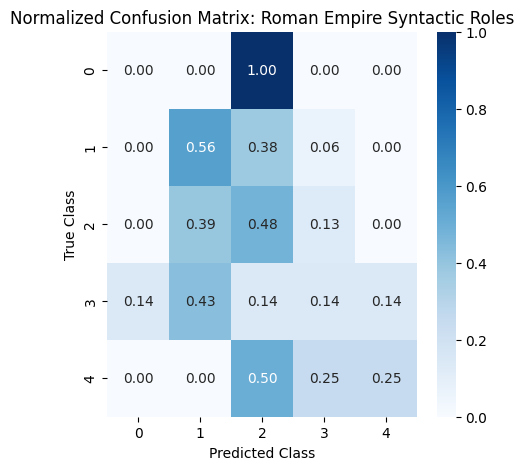

GCN results saved using PyG features.
Training Time 0.4761180877685547


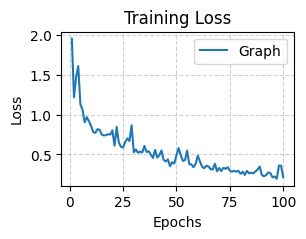

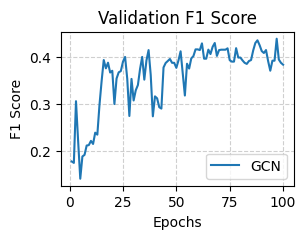

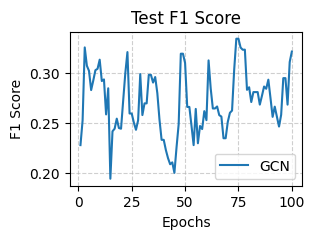

In [47]:
for s_idx in range(10):
    print(f"\n>>> RUNNING SPLIT {s_idx} / 9")
    args['split_idx'] = s_idx
    gcn_run()

In [48]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion,
        model_name="GraphSAGE", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


## GraphSAGE Run


>>> RUNNING SPLIT 0 / 9
Training Graph SAGE
Epoch: 010, Loss: 0.1373, Val F1: 0.4158,Val Acc: 0.6875, Time: 0.00s
Epoch: 020, Loss: 0.0470, Val F1: 0.4820,Val Acc: 0.7250, Time: 0.00s
Epoch: 030, Loss: 0.0161, Val F1: 0.4519,Val Acc: 0.7000, Time: 0.00s
Epoch: 040, Loss: 0.0116, Val F1: 0.5438,Val Acc: 0.7125, Time: 0.00s
Epoch: 050, Loss: 0.0012, Val F1: 0.5682,Val Acc: 0.7250, Time: 0.00s
Epoch: 060, Loss: 0.0054, Val F1: 0.5682,Val Acc: 0.7250, Time: 0.00s
Epoch: 070, Loss: 0.0040, Val F1: 0.5682,Val Acc: 0.7250, Time: 0.00s
Epoch: 080, Loss: 0.0021, Val F1: 0.5532,Val Acc: 0.7000, Time: 0.00s
Epoch: 090, Loss: 0.0005, Val F1: 0.5726,Val Acc: 0.7250, Time: 0.00s
Epoch: 100, Loss: 0.0002, Val F1: 0.5726,Val Acc: 0.7250, Time: 0.01s
Test F1: 0.4653
Test Accuracy: 0.6863


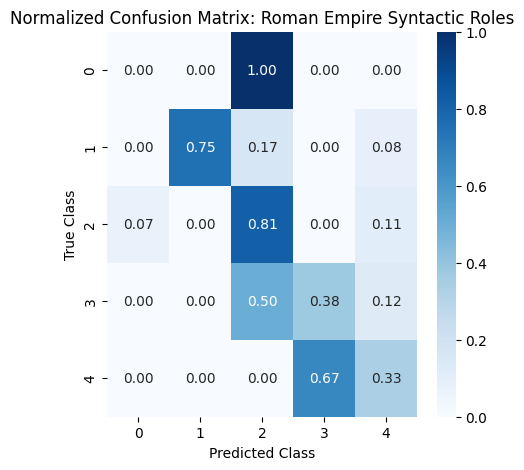

GRAPHSAGE results saved using PyG features.
Training Time 0.48920726776123047


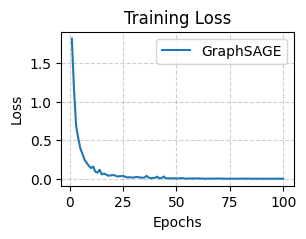

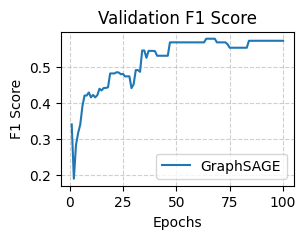

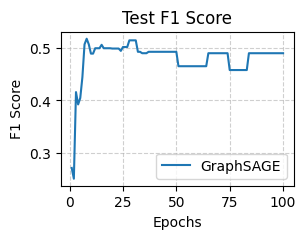


>>> RUNNING SPLIT 1 / 9
Training Graph SAGE
Epoch: 010, Loss: 0.2896, Val F1: 0.3930,Val Acc: 0.6000, Time: 0.00s
Epoch: 020, Loss: 0.0506, Val F1: 0.5360,Val Acc: 0.7125, Time: 0.01s
Epoch: 030, Loss: 0.0061, Val F1: 0.5881,Val Acc: 0.7250, Time: 0.00s
Epoch: 040, Loss: 0.0013, Val F1: 0.5815,Val Acc: 0.7125, Time: 0.00s
Epoch: 050, Loss: 0.0007, Val F1: 0.6265,Val Acc: 0.7375, Time: 0.00s
Epoch: 060, Loss: 0.0014, Val F1: 0.6260,Val Acc: 0.7375, Time: 0.00s
Epoch: 070, Loss: 0.0003, Val F1: 0.6260,Val Acc: 0.7375, Time: 0.01s
Epoch: 080, Loss: 0.0005, Val F1: 0.6260,Val Acc: 0.7375, Time: 0.00s
Epoch: 090, Loss: 0.0003, Val F1: 0.6260,Val Acc: 0.7375, Time: 0.00s
Epoch: 100, Loss: 0.0001, Val F1: 0.6166,Val Acc: 0.7250, Time: 0.00s
Test F1: 0.5979
Test Accuracy: 0.8824


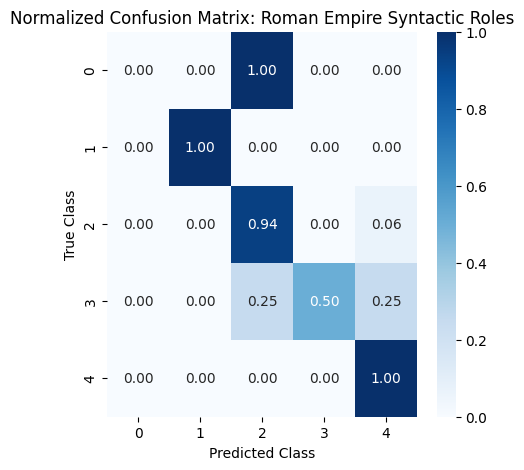

GRAPHSAGE results saved using PyG features.
Training Time 0.47058868408203125


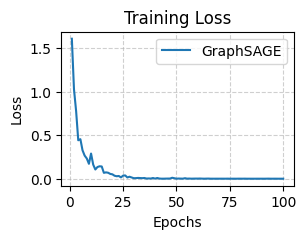

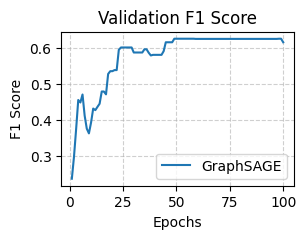

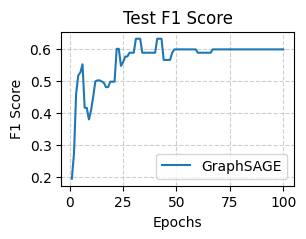


>>> RUNNING SPLIT 2 / 9
Training Graph SAGE
Epoch: 010, Loss: 0.0991, Val F1: 0.5791,Val Acc: 0.7375, Time: 0.00s
Epoch: 020, Loss: 0.0246, Val F1: 0.5774,Val Acc: 0.7250, Time: 0.00s
Epoch: 030, Loss: 0.0052, Val F1: 0.6384,Val Acc: 0.7500, Time: 0.00s
Epoch: 040, Loss: 0.0092, Val F1: 0.6400,Val Acc: 0.7500, Time: 0.00s
Epoch: 050, Loss: 0.0005, Val F1: 0.5904,Val Acc: 0.7250, Time: 0.00s
Epoch: 060, Loss: 0.0008, Val F1: 0.5904,Val Acc: 0.7250, Time: 0.00s
Epoch: 070, Loss: 0.0005, Val F1: 0.5743,Val Acc: 0.7125, Time: 0.00s
Epoch: 080, Loss: 0.0009, Val F1: 0.5743,Val Acc: 0.7125, Time: 0.00s
Epoch: 090, Loss: 0.0004, Val F1: 0.6104,Val Acc: 0.7375, Time: 0.00s
Epoch: 100, Loss: 0.0004, Val F1: 0.6258,Val Acc: 0.7500, Time: 0.00s
Test F1: 0.4152
Test Accuracy: 0.6863


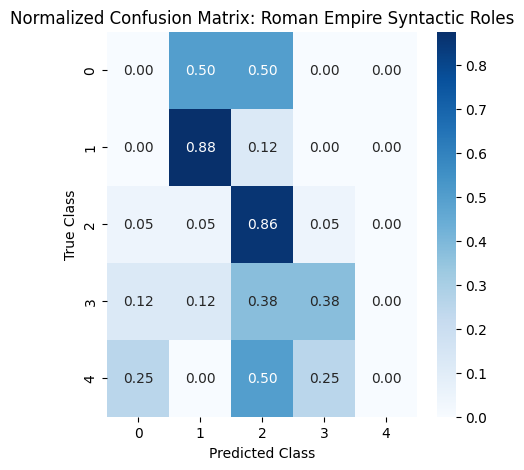

GRAPHSAGE results saved using PyG features.
Training Time 0.4389622211456299


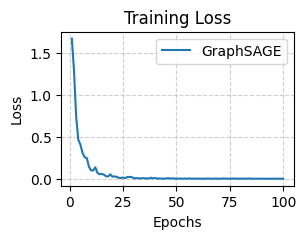

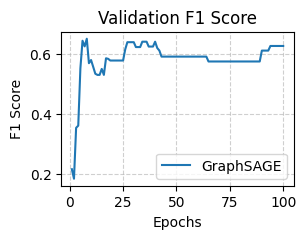

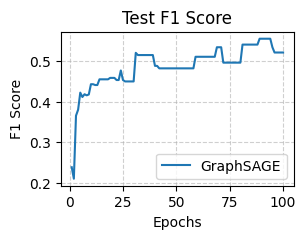


>>> RUNNING SPLIT 3 / 9
Training Graph SAGE
Epoch: 010, Loss: 0.1829, Val F1: 0.4553,Val Acc: 0.6250, Time: 0.01s
Epoch: 020, Loss: 0.0601, Val F1: 0.5059,Val Acc: 0.7625, Time: 0.00s
Epoch: 030, Loss: 0.0101, Val F1: 0.4843,Val Acc: 0.7125, Time: 0.00s
Epoch: 040, Loss: 0.0072, Val F1: 0.5557,Val Acc: 0.7250, Time: 0.00s
Epoch: 050, Loss: 0.0065, Val F1: 0.5681,Val Acc: 0.7250, Time: 0.01s
Epoch: 060, Loss: 0.0016, Val F1: 0.5767,Val Acc: 0.7375, Time: 0.00s
Epoch: 070, Loss: 0.0010, Val F1: 0.5767,Val Acc: 0.7375, Time: 0.01s
Epoch: 080, Loss: 0.0004, Val F1: 0.5730,Val Acc: 0.7375, Time: 0.01s
Epoch: 090, Loss: 0.0004, Val F1: 0.5563,Val Acc: 0.7125, Time: 0.00s
Epoch: 100, Loss: 0.0014, Val F1: 0.5680,Val Acc: 0.7250, Time: 0.00s
Test F1: 0.5964
Test Accuracy: 0.7843


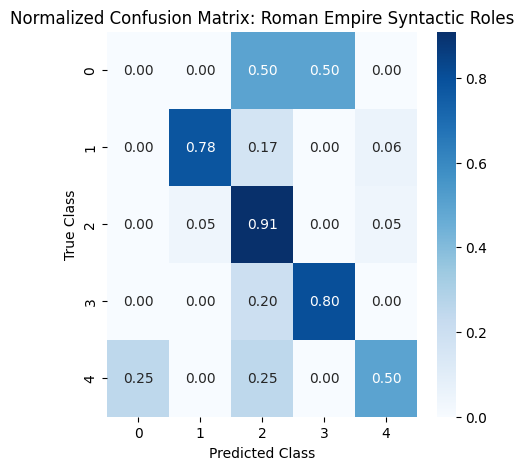

GRAPHSAGE results saved using PyG features.
Training Time 0.6306278705596924


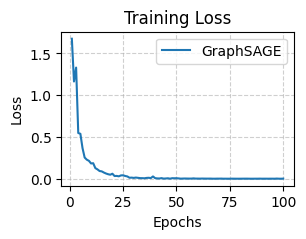

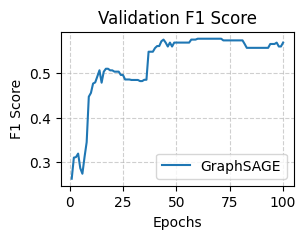

In [ ]:
for s_idx in range(10):
    print(f"\n>>> RUNNING SPLIT {s_idx} / 9")
    args['split_idx'] = s_idx
    graphSage_run()

In [ ]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion,
        model_name="GAT", 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


## GAT Run

Training GAT
Epoch: 010, Loss: 1.1757, Val F1: 0.2728,Val Acc: 0.4750, Time: 0.01s
Epoch: 020, Loss: 0.8653, Val F1: 0.3367,Val Acc: 0.4625, Time: 0.01s
Epoch: 030, Loss: 0.9425, Val F1: 0.4472,Val Acc: 0.5000, Time: 0.01s
Epoch: 040, Loss: 0.8006, Val F1: 0.3649,Val Acc: 0.3875, Time: 0.01s
Epoch: 050, Loss: 0.8306, Val F1: 0.3540,Val Acc: 0.4375, Time: 0.01s
Epoch: 060, Loss: 0.5644, Val F1: 0.3839,Val Acc: 0.4625, Time: 0.01s
Epoch: 070, Loss: 0.5943, Val F1: 0.3243,Val Acc: 0.4250, Time: 0.01s
Epoch: 080, Loss: 0.6838, Val F1: 0.3737,Val Acc: 0.4125, Time: 0.01s
Epoch: 090, Loss: 0.6746, Val F1: 0.4504,Val Acc: 0.4375, Time: 0.01s
Epoch: 100, Loss: 0.6782, Val F1: 0.3371,Val Acc: 0.4625, Time: 0.01s
Test F1: 0.2364
Test Accuracy: 0.4314


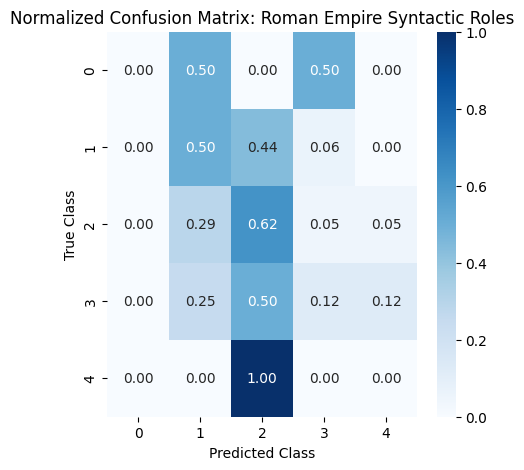

GAT results saved using PyG features.
Training Time 0.7884571552276611


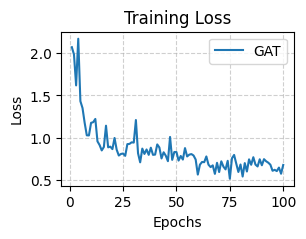

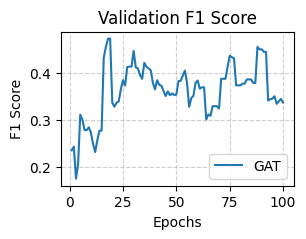

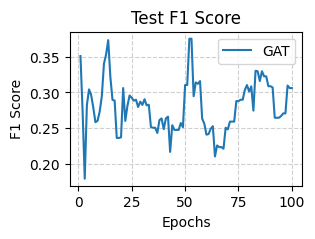

In [ ]:
for s_idx in range(10):
    print(f"\n>>> RUNNING SPLIT {s_idx} / 9")
    args['split_idx'] = s_idx
    gat_run()

In [ ]:
from GCN2 import GCN2

In [ ]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 2
  }

In [ ]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


## GCN2 Run

Training GCN
Epoch: 010, Loss: 1.5023, Val F1: 0.0800,Val Acc: 0.2500, Time: 0.02s
Epoch: 020, Loss: 1.5317, Val F1: 0.0800,Val Acc: 0.2500, Time: 0.02s
Epoch: 030, Loss: 1.4494, Val F1: 0.0800,Val Acc: 0.2500, Time: 0.02s
Epoch: 040, Loss: 1.4452, Val F1: 0.0800,Val Acc: 0.2500, Time: 0.02s
Epoch: 050, Loss: 1.4824, Val F1: 0.1197,Val Acc: 0.2625, Time: 0.02s
Epoch: 060, Loss: 1.3661, Val F1: 0.1261,Val Acc: 0.2625, Time: 0.02s
Epoch: 070, Loss: 1.3962, Val F1: 0.2670,Val Acc: 0.5125, Time: 0.02s
Epoch: 080, Loss: 1.3610, Val F1: 0.2388,Val Acc: 0.4500, Time: 0.02s
Epoch: 090, Loss: 1.3109, Val F1: 0.2029,Val Acc: 0.5000, Time: 0.02s
Epoch: 100, Loss: 1.3348, Val F1: 0.2104,Val Acc: 0.5250, Time: 0.02s
Epoch: 110, Loss: 1.2960, Val F1: 0.2069,Val Acc: 0.5125, Time: 0.02s
Epoch: 120, Loss: 1.2755, Val F1: 0.2093,Val Acc: 0.5125, Time: 0.02s
Epoch: 130, Loss: 1.1850, Val F1: 0.2093,Val Acc: 0.5125, Time: 0.02s
Epoch: 140, Loss: 1.2322, Val F1: 0.2132,Val Acc: 0.5250, Time: 0.02s
Epoch: 

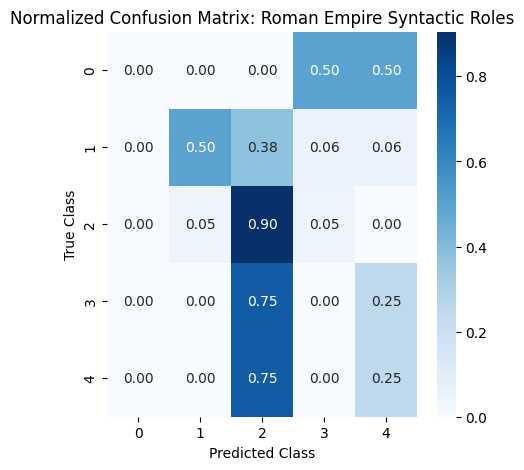

GCN2 results saved using PyG features.
Training Time 6.452502727508545


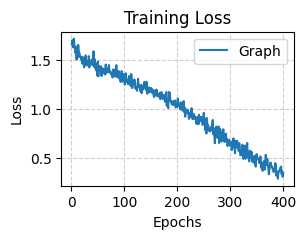

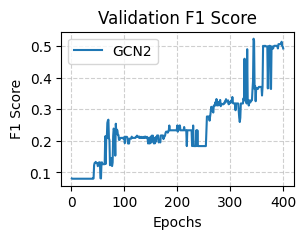

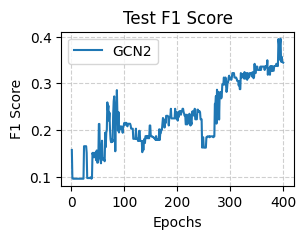

In [ ]:
for s_idx in range(10):
    print(f"\n>>> RUNNING SPLIT {s_idx} / 9")
    args['split_idx'] = s_idx
    gcn2_run()

In [ ]:
from H2GCN import H2GCN

In [ ]:
args = {
      'device': device,
      'num_layers': 2, #Not applicable to H2GCN
      'hidden_dim': 30,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 300,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 2
  }

In [ ]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


## H2GCN Run

Training H2GCN
Epoch: 010, Loss: 0.0996, Val F1: 0.5875,Val Acc: 0.8125, Time: 0.00s
Epoch: 020, Loss: 0.0387, Val F1: 0.8032,Val Acc: 0.8375, Time: 0.00s
Epoch: 030, Loss: 0.0089, Val F1: 0.6940,Val Acc: 0.8250, Time: 0.00s
Epoch: 040, Loss: 0.0050, Val F1: 0.7474,Val Acc: 0.8250, Time: 0.00s
Epoch: 050, Loss: 0.0044, Val F1: 0.7474,Val Acc: 0.8250, Time: 0.00s
Epoch: 060, Loss: 0.0025, Val F1: 0.7474,Val Acc: 0.8250, Time: 0.00s
Epoch: 070, Loss: 0.0032, Val F1: 0.7549,Val Acc: 0.8375, Time: 0.00s
Epoch: 080, Loss: 0.0029, Val F1: 0.7474,Val Acc: 0.8250, Time: 0.00s
Epoch: 090, Loss: 0.0088, Val F1: 0.7474,Val Acc: 0.8250, Time: 0.00s
Epoch: 100, Loss: 0.0031, Val F1: 0.6959,Val Acc: 0.8000, Time: 0.00s
Epoch: 110, Loss: 0.0031, Val F1: 0.7104,Val Acc: 0.8125, Time: 0.00s
Epoch: 120, Loss: 0.0027, Val F1: 0.5849,Val Acc: 0.8000, Time: 0.00s
Epoch: 130, Loss: 0.0024, Val F1: 0.5473,Val Acc: 0.7875, Time: 0.00s
Epoch: 140, Loss: 0.0047, Val F1: 0.5573,Val Acc: 0.7875, Time: 0.00s
Epoch

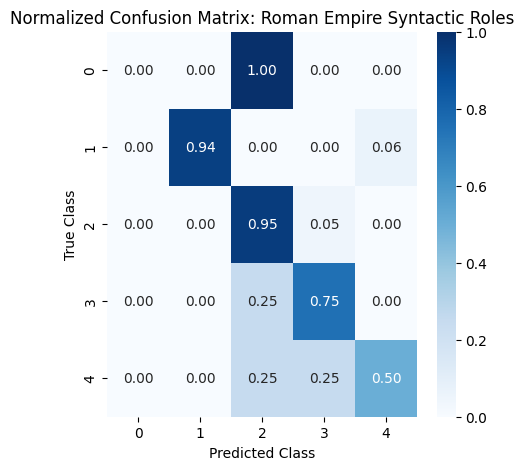

H2GCN results saved using PyG features.
Training Time 1.3229997158050537


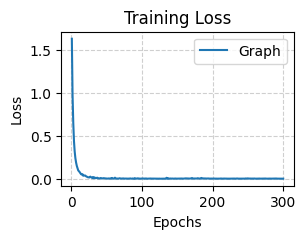

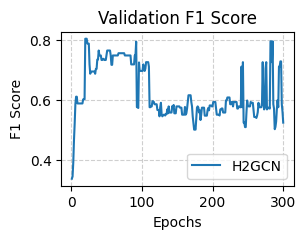

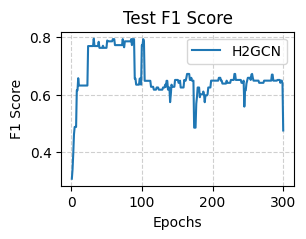

In [ ]:
for s_idx in range(10):
    print(f"\n>>> RUNNING SPLIT {s_idx} / 9")
    args['split_idx'] = s_idx
    h2GCN_run()